In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel(r"C:Users\THIS\Downloads\Financial_Sample (1).xlsx")

In [3]:
df.shape

(700, 16)

In [4]:
df.head(2)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20.0,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20.0,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              692 non-null    object        
 1   Country              689 non-null    object        
 2   Product              692 non-null    object        
 3   Discount Band        638 non-null    object        
 4   Units Sold           695 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           693 non-null    float64       
 7   Gross Sales          695 non-null    float64       
 8   Discounts            695 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

In [6]:
# Checking Missing Values
df.isnull().sum()

Segment                 8
Country                11
Product                 8
Discount Band          62
Units Sold              5
Manufacturing Price     0
Sale Price              7
Gross Sales             5
Discounts               5
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [7]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

In [14]:
for col in df.columns:
    if df[col].isnull().sum()>0:
        print(col ,'\t', df[col].dtype , '\t' , df[col].isnull().sum())

Segment 	 object 	 8
Country 	 object 	 11
Product 	 object 	 8
Discount Band 	 object 	 62
Units Sold 	 float64 	 5
Sale Price 	 float64 	 7
Gross Sales 	 float64 	 5
Discounts 	 float64 	 5


In [12]:
df.Segment

0            Government
1            Government
2             Midmarket
3             Midmarket
4             Midmarket
             ...       
695      Small Business
696      Small Business
697          Government
698          Government
699    Channel Partners
Name: Segment, Length: 700, dtype: object

In [13]:
df.Segment.unique()

array(['Government', 'Midmarket', 'Channel Partners', 'Enterprise',
       'Small Business', nan], dtype=object)

In [21]:
df.Segment.value_counts()

Segment
Government          294
Midmarket           100
Enterprise          100
Small Business      100
Channel Partners     98
Name: count, dtype: int64

In [19]:
import matplotlib.pyplot as plt

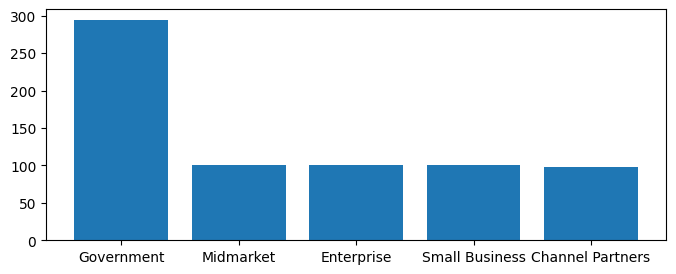

In [24]:
plt.figure(figsize=(8,3))
plt.bar(df.Segment.value_counts().reset_index()['Segment'],df.Segment.value_counts().reset_index()['count'])
plt.show()

In [27]:
df.Segment.mode()

0    Government
Name: Segment, dtype: object

In [28]:
df.Segment.mode()[0]

'Government'

In [30]:
df.Profit.mean()

np.float64(24133.860371428567)

In [33]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

In [38]:
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum()>0:
        print(col , "\tMode :",df[col].mode()[0])

Segment 	Mode : Government
Country 	Mode : France
Product 	Mode : Paseo
Discount Band 	Mode : High


In [40]:
# Filling missing value in Categorical/object/string/text column with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna( value= df[col].mode()[0] )

In [41]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             5
Manufacturing Price    0
Sale Price             7
Gross Sales            5
Discounts              5
 Sales                 0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

In [44]:
# Filling missing values in numerical columns
for col in df.select_dtypes(include='float').columns:
    df[col] = df[col].fillna(value=df[col].mean())

In [45]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
 Sales                 0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64